In [ ]:
from google.colab import files

uploaded = files.upload()

Saving archive.zip to archive.zip


In [ ]:
import os

print(os.listdir("/content"))

['.config', 'archive.zip', 'sample_data']


In [ ]:
import zipfile
import os

# ZIP file name
zip_path = "/content/archive.zip"

# Folder where the dataset will be extracted
extract_path = "/content/hands_dataset"

# Create the folder if it doesn't exist
os.makedirs(extract_path, exist_ok=True)

# Extract the ZIP file
with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("✅ Dataset extracted successfully!")

# Show extracted files/folders
print("\nContents of the extracted folder:")
print(os.listdir(extract_path))

✅ Dataset extracted successfully!

Contents of the extracted folder:
['cards', 'tarot-images.json']


In [ ]:
import os

for root, dirs, files in os.walk("/content/hands_dataset"):
    print("Folder:", root)
    print("Subfolders:", dirs)
    print("Files:", files[:5])  # Show only first 5 files
    print("-" * 50)

Folder: /content/hands_dataset
Subfolders: ['cards']
Files: ['tarot-images.json']
--------------------------------------------------
Folder: /content/hands_dataset/cards
Subfolders: []
Files: ['c14.jpg', 's09.jpg', 's01.jpg', 'p02.jpg', 's05.jpg']
--------------------------------------------------


In [ ]:
import os

for root, dirs, files in os.walk("/content/hands_dataset"):
    print("=" * 60)
    print("Folder :", root)
    print("Subfolders :", dirs)
    print("Number of Files :", len(files))
    print("First 10 Files :", files[:10])

Folder : /content/hands_dataset
Subfolders : ['cards']
Number of Files : 1
First 10 Files : ['tarot-images.json']
Folder : /content/hands_dataset/cards
Subfolders : []
Number of Files : 78
First 10 Files : ['c14.jpg', 's09.jpg', 's01.jpg', 'p02.jpg', 's05.jpg', 'w12.jpg', 'm21.jpg', 'c06.jpg', 's07.jpg', 'c02.jpg']


In [ ]:
import os

total_images = 0

for root, dirs, files in os.walk("/content/hands_dataset"):
    for file in files:
        if file.lower().endswith((".jpg", ".jpeg", ".png")):
            total_images += 1

print("========== DATASET OVERVIEW ==========")
print("Total Images :", total_images)

========== DATASET OVERVIEW ==========
Total Images : 78


In [5]:
import random
import matplotlib.pyplot as plt
from PIL import Image
import os

image_files = []

for root, dirs, files in os.walk("/content/hands_dataset"):
    for file in files:
        if file.lower().endswith( (".jpg",".jpeg",".png")):
            image_files.append(os.path.join(root,file))

# Check if image_files is empty
if not image_files:
    print("No image files found in the specified dataset path. Please ensure the dataset is correctly extracted and contains image files.")
else:
    plt.figure(figsize=(12,12))

    # Display up to 9 images, or fewer if not enough are found
    for i in range(min(9, len(image_files))):
        img = Image.open(random.choice(image_files))

        plt.subplot(3,3,i+1)
        plt.imshow(img)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

No image files found in the specified dataset path. Please ensure the dataset is correctly extracted and contains image files.


In [ ]:
print("Total Images :", len(image_files))

Total Images : 78


In [ ]:
from collections import Counter

sizes=[]

for image in image_files:

    img=Image.open(image)

    sizes.append(img.size)

Counter(sizes)

Counter({(350, 600): 78})

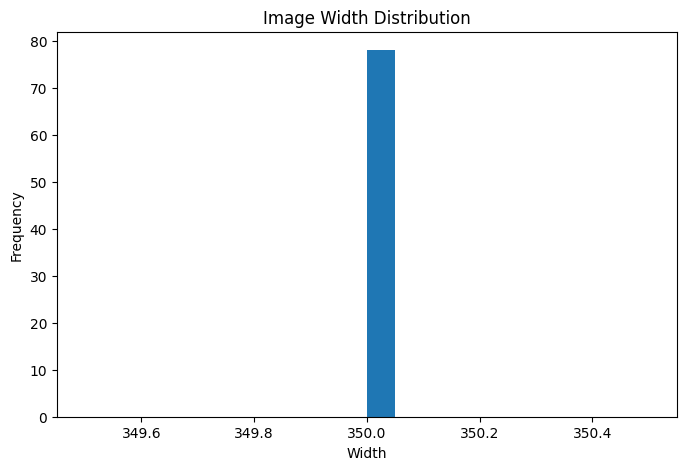

In [ ]:
width=[]

for image in image_files:

    img=Image.open(image)

    width.append(img.size[0])

plt.figure(figsize=(8,5))

plt.hist(width,bins=20)

plt.title("Image Width Distribution")

plt.xlabel("Width")

plt.ylabel("Frequency")

plt.show()

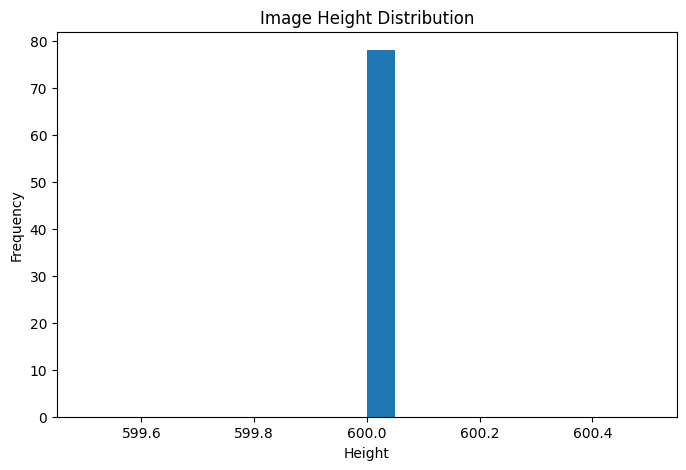

In [ ]:
height=[]

for image in image_files:

    img=Image.open(image)

    height.append(img.size[1])

plt.figure(figsize=(8,5))

plt.hist(height,bins=20)

plt.title("Image Height Distribution")

plt.xlabel("Height")

plt.ylabel("Frequency")

plt.show()

In [ ]:
formats=[]

for image in image_files:

    img=Image.open(image)

    formats.append(img.format)

import pandas as pd

print(pd.Series(formats).value_counts())

JPEG    78
Name: count, dtype: int64


In [ ]:
modes=[]

for image in image_files:

    img=Image.open(image)

    modes.append(img.mode)

print(pd.Series(modes).value_counts())

RGB    78
Name: count, dtype: int64


In [ ]:
bad=[]

for image in image_files:

    try:

        img=Image.open(image)

        img.verify()

    except:

        bad.append(image)

print("Corrupted Images :",len(bad))

Corrupted Images : 0


In [ ]:
import numpy as np

print("Average Width :",np.mean(width))
print("Average Height :",np.mean(height))

Average Width : 350.0
Average Height : 600.0


In [ ]:
img=Image.open(image_files[0])

print(img.mode)

RGB


In [ ]:
import os
import cv2
import numpy as np

image_size = 224

images = []

labels = []

dataset_path="/content/hands_dataset"

for root,dirs,files in os.walk(dataset_path):

    for file in files:

        if file.endswith((".jpg",".png",".jpeg")):

            img=cv2.imread(os.path.join(root,file))

            img=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)

            img=cv2.resize(img,(224,224))

            img=img/255.0

            images.append(img)

            labels.append(os.path.basename(root))

X=np.array(images)

y=np.array(labels)

print(X.shape)

(78, 224, 224, 3)


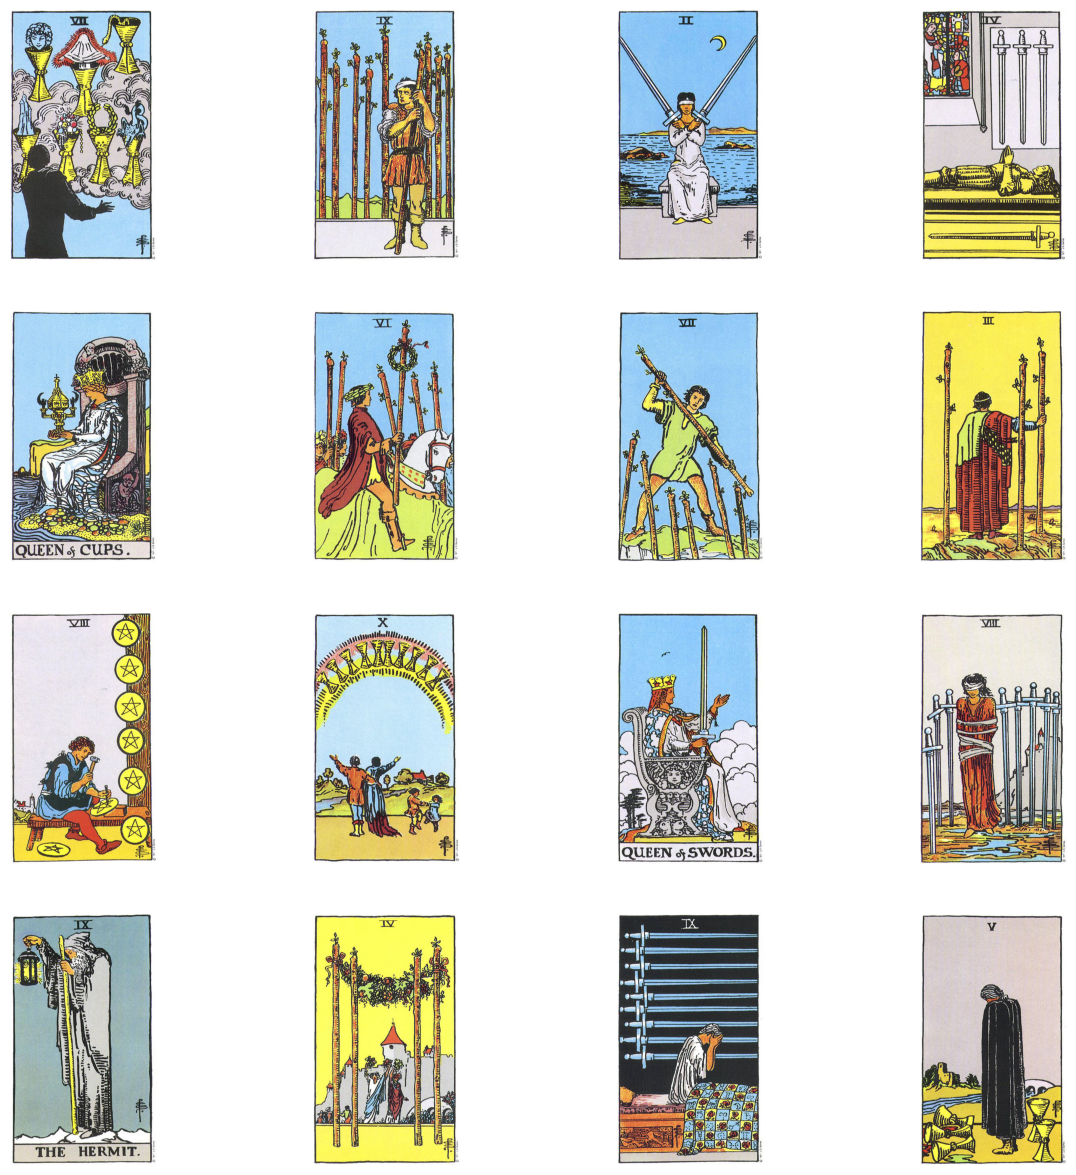

In [ ]:
plt.figure(figsize=(15,15))

for i in range(16):

    img=Image.open(random.choice(image_files))

    plt.subplot(4,4,i+1)

    plt.imshow(img)

    plt.axis("off")

plt.show()

In [ ]:
import cv2
import numpy as np

pixels=[]

for image in image_files[:100]:

    img=cv2.imread(image)

    pixels.append(np.mean(img))

print("Average Pixel Value :",np.mean(pixels))

Average Pixel Value : 164.80812901912904


In [ ]:
from collections import Counter

names=[os.path.basename(x) for x in image_files]

duplicate=[item for item,count in Counter(names).items() if count>1]

print("Duplicate Files :",len(duplicate))

Duplicate Files : 0


In [ ]:
print("========== DATASET SUMMARY ==========")

print("Total Images :",len(image_files))

print("Average Width :",np.mean(width))

print("Average Height :",np.mean(height))

print("Image Format :",pd.Series(formats).mode()[0])

print("Color Mode :",pd.Series(modes).mode()[0])

print("Corrupted Images :",len(bad))

========== DATASET SUMMARY ==========
Total Images : 78
Average Width : 350.0
Average Height : 600.0
Image Format : JPEG
Color Mode : RGB
Corrupted Images : 0


In [ ]:
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

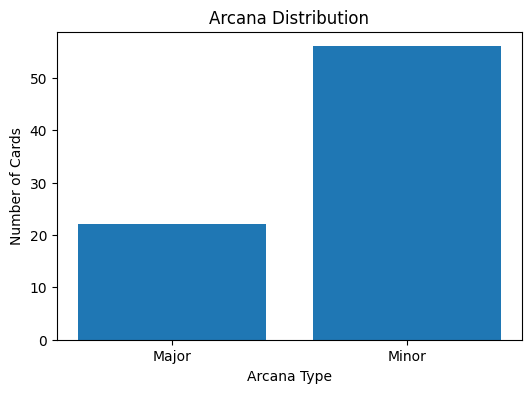

In [ ]:
import matplotlib.pyplot as plt

categories = ["Major", "Minor"]
values = [22, 56]

plt.figure(figsize=(6,4))
plt.bar(categories, values)
plt.title("Arcana Distribution")
plt.xlabel("Arcana Type")
plt.ylabel("Number of Cards")
plt.show()

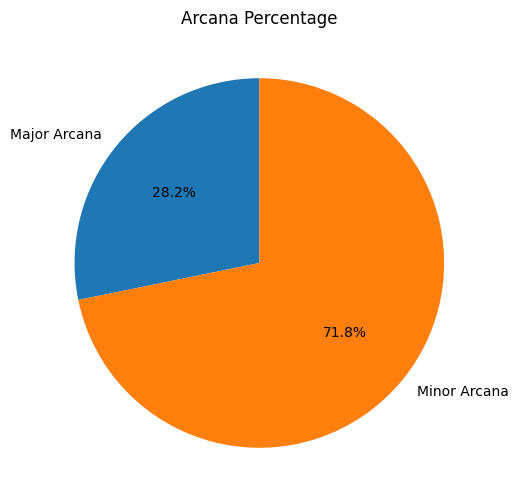

In [ ]:
import matplotlib.pyplot as plt

labels = ["Major Arcana", "Minor Arcana"]
sizes = [22, 56]

plt.figure(figsize=(6,6))
plt.pie(sizes, labels=labels, autopct="%1.1f%%", startangle=90)
plt.title("Arcana Percentage")
plt.show()

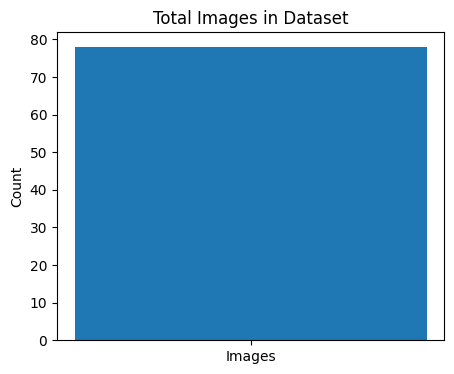

In [ ]:
import os
import matplotlib.pyplot as plt

image_count = 0

for root, dirs, files in os.walk("/content/hands_dataset"):
    for file in files:
        if file.lower().endswith((".jpg", ".jpeg", ".png")):
            image_count += 1

plt.figure(figsize=(5,4))
plt.bar(["Images"], [image_count])
plt.title("Total Images in Dataset")
plt.ylabel("Count")
plt.show()

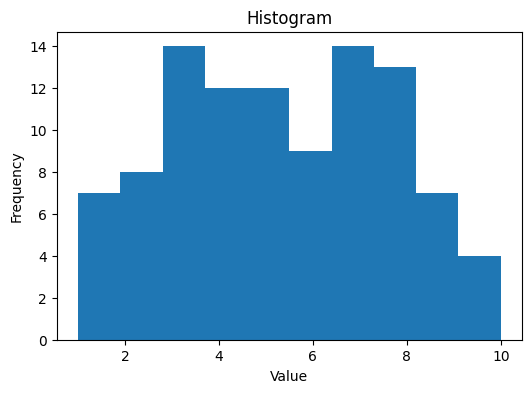

In [ ]:
import matplotlib.pyplot as plt
import random

data = [random.randint(1,10) for i in range(100)]

plt.figure(figsize=(6,4))
plt.hist(data, bins=10)
plt.title("Histogram")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.show()